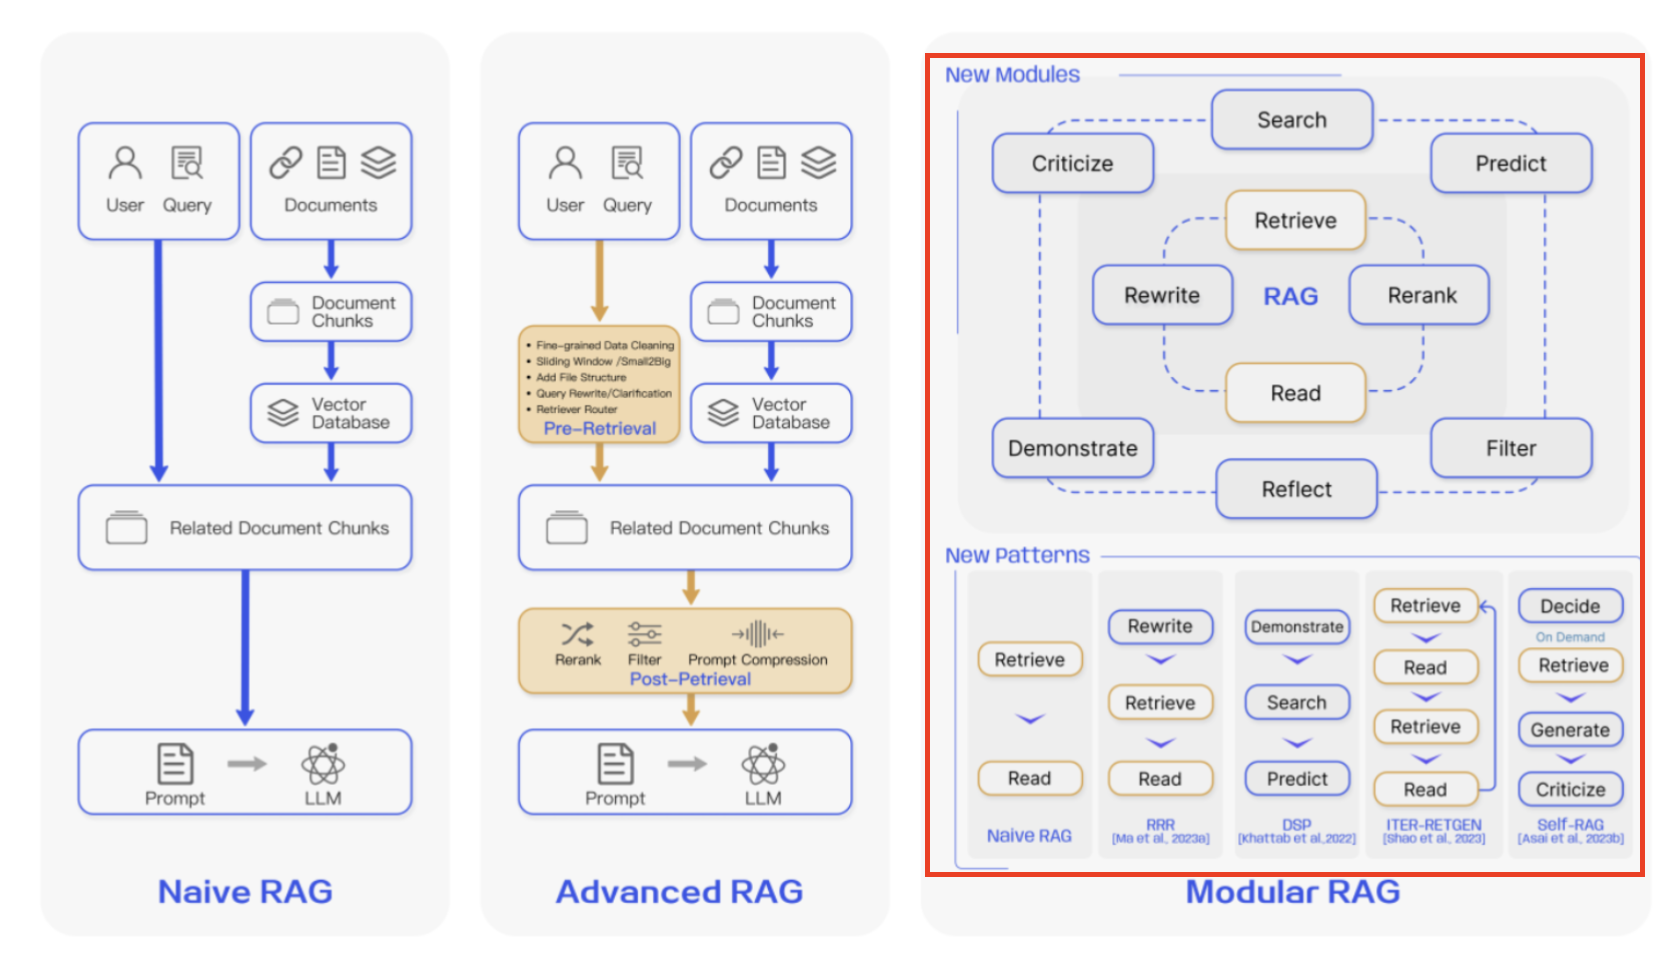

# LangGraph를 이용한 Self-RAG (Self-Reflective Retrieval-Augmented Generation)

## [1. Self-RAG 개요](https://www.machinelearningplus.com/gen-ai/self-rag-explained-teaching-ai-to-evaluate-its-own-responses/)
- Self-RAG는 기존 RAG 시스템에 **자체 평가(Self-Reflection)** 메커니즘을 추가한 고급 RAG 시스템입니다. 
    - 이 시스템은 검색의 필요성을 판단하고, 검색된 문서의 관련성을 평가하며, 생성된 답변의 품질을 자체적으로 검증합니다.
- Self-RAG는 기존 RAG 시스템의 한계를 극복하고, 더욱 지능적이고 신뢰할 수 있는 질의응답 시스템을 구현할 수 있게 해줍니다. 

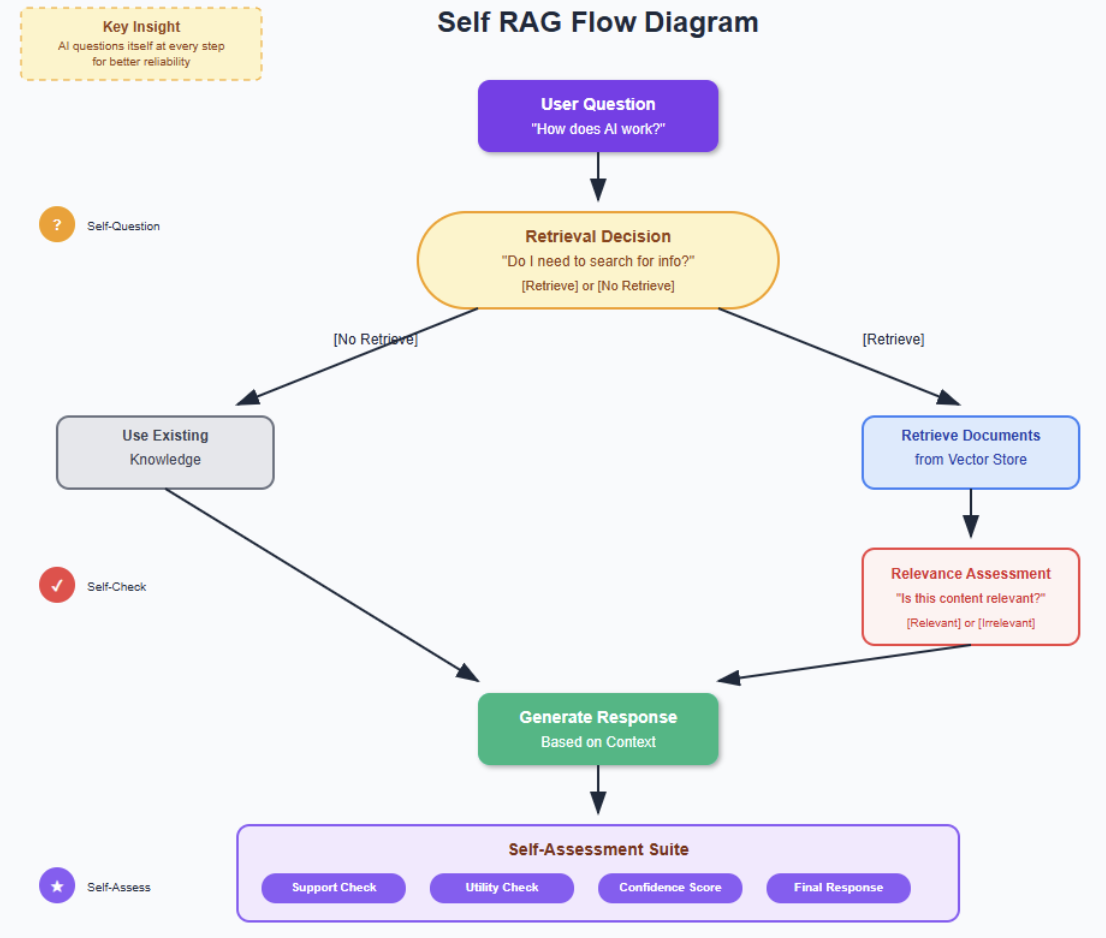

### 1.1 기존 RAG vs Self-RAG

| 구분 | 기존 RAG | Self-RAG |
|------|----------|----------|
| 검색 | 항상 검색 수행 | 필요시에만 검색 |
| 평가 | 없음 | 검색 결과 관련성 평가 |
| 생성 | 단순 생성 | 자체 평가 후 생성 |
| 품질 관리 | 없음 | 답변 품질 자체 검증 |
| 출처 표시 | 선택적 | 필수적 |


### 1.2 Corrective RAG vs Self-RAG
| 구분 | Corrective RAG | Self RAG |
|------|----------------|----------|
| **초점** | 검색된 문서 품질 교정 | 생성된 답변 자체 검증 |
| **개입 시점** | 문서 검색 후, 답변 생성 전 | 답변 생성 후 |
| **평가 대상** | 검색 문서의 관련성 | 생성된 답변의 정확성 |
| **교정 방법** | 문서 재검색, 재작성 | 답변 재생성, 수정 |


### 1.2 Self-RAG의 핵심 구성 요소

1. **Retrieve Token**: 검색이 필요한지 판단
2. **Relevance Token**: 검색된 문서의 관련성 평가  
3. **Support Token**: 답변이 검색 결과로 뒷받침되는지 평가
4. **Utility Token**: 최종 답변의 유용성 평가


### 1.3 Self-RAG 워크플로우

```
질문 입력 → 검색 필요성 판단 → 문서 검색 → 관련성 평가 → 답변 생성 → 품질 검증 → 최종 답변
```

## 2. 환경 설정


### API 키 설정
- [OpenAI API 키](https://platform.openai.com/api-keys)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 3. LangGraph State 정의

Self-RAG 시스템의 상태를 관리하기 위한 State 클래스를 정의합니다.


In [2]:
from typing import List, TypedDict
from langchain_core.documents import Document

class SelfRAGState(TypedDict):
    """Self-RAG 시스템의 상태를 정의하는 클래스"""
    
    # 입력 정보
    question: str  # 사용자 질문
    
    # 검색 관련
    need_retrieval: bool  # 검색 필요 여부
    retrieved_docs: List[Document]  # 검색된 문서들
    relevant_docs: List[Document]  # 관련성이 있는 문서들
    
    # 답변 생성 관련
    answer: str  # 생성된 답변
    sources: List[str]  # 출처 정보
    
    # 평가 관련
    relevance_score: float  # 관련성 점수
    support_score: float  # 지지도 점수
    utility_score: float  # 유용성 점수
    
    # 최종 결과
    final_answer: str  # 최종 답변 (출처 포함)
    confidence: str  # 신뢰도 ("high", "medium", "low", "unknown")

print("SelfRAGState 클래스 정의 완료!")


SelfRAGState 클래스 정의 완료!


## 4. 벡터스토어


### Embedding Model

In [3]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

### Elasticsearch Client

In [4]:
from elasticsearch import Elasticsearch
import warnings

# SSL 경고 무시 (개발 환경용)
warnings.filterwarnings('ignore')

# Elasticsearch 클라이언트 생성
# elasticsearch 9.x는 명시적인 scheme 지정이 필요합니다
try:
    es_client = Elasticsearch(
        ["http://localhost:9200"],  # 리스트 형태로, scheme 포함
        basic_auth=("elastic", "changeme123!"),  # 인증 정보 (보안 활성화 시 필수)
        verify_certs=False,
        ssl_show_warn=False,
        request_timeout=30,
        max_retries=3,
        retry_on_timeout=True,
        # 호환성 헤더 비활성화 (개발 환경용)
        headers={"accept": "application/json", "content-type": "application/json"}
    )
    
    # 연결 확인
    if es_client.ping():
        print("Elasticsearch 연결 성공!")
        print()
        
        # 클러스터 정보
        info = es_client.info()
        print(f"버전: {info['version']['number']}")
        print(f"클러스터 이름: {info['cluster_name']}")
        print(f"노드 이름: {info['name']}")
        print()
        print(f"Elasticsearch URL: http://localhost:9200")
    else:
        print("Elasticsearch 연결 실패 (ping 실패)")
        
except Exception as e:
    print("Elasticsearch 연결 중 오류 발생:")
    print(f"   에러 타입: {type(e).__name__}")
    print(f"   에러 메시지: {str(e)}")

Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1

Elasticsearch URL: http://localhost:9200


> Elasticsearch vectorstore 생성 완료

In [5]:
from common.elasticsearch_vector import ElasticsearchVectorStore

# 인덱스 이름
index_name = "rag_keywords"

vectorstore = ElasticsearchVectorStore(
    es_client=es_client,
    index_name=index_name,
    embeddings=embeddings,
    k=2
)

print("Elasticsearch vectorstore 생성 완료")

Elasticsearch vectorstore 생성 완료


In [6]:
web_result =  vectorstore.hybrid_search_with_score("HTML이란?", k=3)

for result, _ in web_result:
    print("="*50)
    print(f"출처: {result.metadata['source']} / 내용: {result.page_content[:50]}..")

출처: data/web-keywords.txt / 내용: HTML (HyperText Markup Language)

정의: HTML은 웹 페이지의..
출처: data/web-keywords.txt / 내용: DOM (Document Object Model)

정의: DOM은 HTML 문서의 구조를..
출처: data/web-keywords.txt / 내용: GraphQL

정의: GraphQL은 API를 위한 쿼리 언어이자 런타임입니다. 클라이언..


## 5. Self-RAG 핵심 함수들 구현

Self-RAG의 각 단계를 처리하는 함수들을 구현합니다.


### LLM 모델 초기화

In [7]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### 검색이 필요한지 판단하는 함수

In [8]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def decide_retrieval(state: SelfRAGState) -> SelfRAGState:
    """검색이 필요한지 판단하는 함수"""
    
    question = state["question"]
    
    # 검색 필요성 판단 프롬프트
    retrieval_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 질문을 분석하여 외부 지식이 필요한지 판단하는 전문가입니다.

            다음 기준으로 판단하세요:
            - 일반적인 인사말이나 간단한 질문: 검색 불필요
            - 특정 기술, 개념, 정의에 대한 질문: 검색 필요
            - 복잡한 설명이나 전문 지식이 필요한 질문: 검색 필요

        'YES' 또는 'NO'로만 답변하세요."""),
        ("human", "질문: {question}")
    ])
    
    chain = retrieval_prompt | llm | StrOutputParser()
    result = chain.invoke({"question": question})
    
    need_retrieval = result.strip().upper() == "YES"
    
    print(f"검색 필요성 판단: {'필요' if need_retrieval else '불필요'}")
    
    return {
        **state,
        "need_retrieval": need_retrieval
    }


### 문서를 검색하는 함수

In [9]:
def retrieve_documents(state: SelfRAGState) -> SelfRAGState:
    """문서를 검색하는 함수"""
    
    if not state["need_retrieval"]:
        print("검색이 필요하지 않아 건너뜁니다.")
        return {
            **state,
            "retrieved_docs": []
        }
    
    question = state["question"]
    
    # 유사한 문서 검색
    results = vectorstore.hybrid_search_with_score(question, k=5)

    # Document 객체로 변환
    retrieved_docs = []
    for doc, similarity_score in results:
        retrieved_docs.append(Document(
            page_content=doc.page_content,
            metadata={
                **doc.metadata,
                "similarity_score": similarity_score  # 클 수록 유사함 
            }
        ))
    
    print(f"{len(retrieved_docs)}개의 문서를 검색했습니다.")
    
    return {
        **state,
        "retrieved_docs": retrieved_docs
    }
    

### 검색된 문서의 관련성을 평가하는 함수

In [10]:
def evaluate_relevance(state: SelfRAGState) -> SelfRAGState:
    """검색된 문서의 관련성을 평가하는 함수"""
    
    retrieved_docs = state["retrieved_docs"]
    
    if not retrieved_docs:
        print("검색된 문서가 없어 관련성 평가를 건너뜁니다.")
        return {
            **state,
            "relevant_docs": [],
            "relevance_score": 0.0
        }
    
    question = state["question"]
    relevant_docs = []
    relevance_scores = []
    
    # 관련성 평가 프롬프트
    relevance_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 문서의 관련성을 평가하는 전문가입니다.

        주어진 질문과 문서가 얼마나 관련이 있는지 평가하세요.
        - 매우 관련있음: 5점
        - 관련있음: 4점  
        - 보통: 3점
        - 약간 관련있음: 2점
        - 관련없음: 1점

        점수만 숫자로 답변하세요 (1-5)."""),
        ("human", "질문: {question}\n\n문서: {document}")
    ])
    
    chain = relevance_prompt | llm | StrOutputParser()
    
    for doc in retrieved_docs:
        try:
            score_str = chain.invoke({
                "question": question,
                "document": doc.page_content
            })
            score = float(score_str.strip())
            
            if score >= 3.0:  # 3점 이상만 관련 문서로 간주
                relevant_docs.append(doc)
                relevance_scores.append(score)
                
        except ValueError:
            print(f"점수 파싱 오류: {score_str}")
            continue
    
    avg_relevance = sum(relevance_scores) / len(relevance_scores) if relevance_scores else 0.0
    
    print(f"{len(relevant_docs)}개의 관련 문서를 선별했습니다. (평균 관련성: {avg_relevance:.2f})")
    
    return {
        **state,
        "relevant_docs": relevant_docs,
        "relevance_score": avg_relevance
    }

### 답변을 생성하고 출처를 표시하는 함수

In [11]:
def __generate_answer_of_no_relevant_docs(state: SelfRAGState) -> SelfRAGState:
    # 관련 문서가 없는 경우
    print("관련 문서가 없어 일반적인 답변을 생성합니다.")
    
    general_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 도움이 되는 AI 어시스턴트입니다.

        주어진 질문에 대해 다음 규칙을 따르세요:
        1. 일반적인 인사말이나 간단한 대화는 친근하게 답변하세요.
        2. 전문적인 기술 용어나 복잡한 개념에 대한 질문이라면 "죄송하지만 해당 질문에 대한 정확한 정보를 제공할 수 없습니다"라고 답변하세요.
        3. 확실하지 않은 내용은 추측하지 마세요."""),
        ("human", "질문: {question}")
    ])
    
    chain = general_prompt | llm | StrOutputParser()
    answer = chain.invoke({"question": state["question"]})
    
    return {
        **state,
        "answer": answer,
        "sources": [],
        "confidence": "low"
    }

In [12]:
def __generate_answer_of_relevant_docs(state: SelfRAGState) -> SelfRAGState:
    question = state["question"]
    relevant_docs = state["relevant_docs"]
    
    # 관련 문서가 있는 경우
    context = "\n\n".join([
        f"문서 {i+1}: {doc.page_content}" 
        for i, doc in enumerate(relevant_docs)
    ])
    
    # 답변 생성 프롬프트
    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 주어진 문서를 바탕으로 정확한 답변을 제공하는 전문가입니다.

        다음 규칙을 따르세요:
        1. 주어진 문서의 내용만을 바탕으로 답변하세요
        2. 문서에 없는 내용은 추측하지 마세요
        3. 답변은 명확하고 구체적으로 작성하세요
        4. 한국어로 답변하세요"""),
        ("human", 
        """
        질문: {question}

        참고 문서:
        {context}

        위 문서를 바탕으로 질문에 답변해주세요.""")
    ])
    
    chain = answer_prompt | llm | StrOutputParser()
    answer = chain.invoke({
        "question": question,
        "context": context
    })
    
    # 출처 정보 생성 (파일명으로 표시)
    sources = []
    for doc in relevant_docs:
        source_path = doc.metadata.get("source", "알 수 없음")
        # 파일 경로에서 파일명만 추출
        filename = source_path.split("/")[-1] if "/" in source_path else source_path
        sources.append(f"파일: {filename}")
    
    print(f"답변 생성 완료. 출처: {len(sources)}개")
    
    return {
        **state,
        "answer": answer,
        "sources": sources,
        "confidence": "high" if len(relevant_docs) >= 2 else "medium"
    }

In [13]:
def generate_answer(state: SelfRAGState) -> SelfRAGState:
    """답변을 생성하고 출처를 표시하는 함수"""
    
    if not state.get("relevant_docs"):
        return __generate_answer_of_no_relevant_docs(state)
    
    return __generate_answer_of_relevant_docs(state)

### 답변이 검색 결과로 뒷받침되는지 평가하는 함수

In [14]:
def evaluate_support(state: SelfRAGState) -> SelfRAGState:
    """답변이 검색 결과로 뒷받침되는지 평가하는 함수"""
    
    answer = state["answer"]
    relevant_docs = state["relevant_docs"]
    
    if not relevant_docs:
        return {
            **state,
            "support_score": 0.0
        }
    
    context = "\n".join([doc.page_content for doc in relevant_docs])
    
    # 지지도 평가 프롬프트
    support_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 답변이 주어진 문서로 얼마나 뒷받침되는지 평가하는 전문가입니다.

        다음 기준으로 평가하세요:
        - 완전히 뒷받침됨: 5점
        - 대부분 뒷받침됨: 4점
        - 부분적으로 뒷받침됨: 3점
        - 약간 뒷받침됨: 2점
        - 뒷받침되지 않음: 1점

        점수만 숫자로 답변하세요 (1-5)."""),
        ("human", "답변: {answer}\n\n참고 문서: {context}")
    ])
    
    chain = support_prompt | llm | StrOutputParser()
    
    try:
        score_str = chain.invoke({
            "answer": answer,
            "context": context
        })
        support_score = float(score_str.strip())
    except ValueError:
        support_score = 3.0  # 기본값
    
    print(f"지지도 평가: {support_score}/5")
    
    return {
        **state,
        "support_score": support_score
    }

### 최종 답변을 생성하는 함수 (출처 포함)

In [15]:
def create_final_answer(state: SelfRAGState) -> SelfRAGState:
    """최종 답변을 생성하는 함수 (출처 포함)"""
    
    answer = state["answer"]
    sources = state["sources"]
    confidence = state["confidence"]
    
    # 신뢰도가 낮거나 출처가 없는 경우
    if confidence == "low" or not sources:
        if "정확한 정보를 제공할 수 없습니다" in answer or "모르겠습니다" in answer:
            final_answer = "죄송하지만 해당 질문에 대한 정확한 정보를 제공할 수 없습니다."
        else:
            final_answer = answer
        
        return {
            **state,
            "final_answer": final_answer,
            "confidence": "unknown"
        }
    
    # 출처가 있는 경우 출처 정보 추가
    final_answer = answer + "\n\n**출처:**\n"
    for i, source in enumerate(sources, 1):
        final_answer += f"{i}. {source}\n"
    
    print("최종 답변 생성 완료")
    
    return {
        **state,
        "final_answer": final_answer
    }


## 6. LangGraph 워크플로우 구성

Self-RAG 시스템의 전체 워크플로우를 LangGraph로 구성합니다.


### 검색 필요성에 따라 다음 단계를 결정하는 조건부 함수

In [16]:
def should_retrieve(state: SelfRAGState) -> str:
    """검색 필요성에 따라 다음 단계를 결정하는 조건부 함수"""
    if state["need_retrieval"]:
        return "retrieve"
    else:
        return "generate"

### Self-RAG 워크플로우를 생성하는 함수

In [17]:
from langgraph.graph import StateGraph, END

def create_self_rag_workflow():
    """Self-RAG 워크플로우를 생성하는 함수"""
    
    ###############################
    # StateGraph 생성
    ###############################
    workflow = StateGraph(SelfRAGState)
    
    ###############################
    # 노드 추가 
    ###############################
    workflow.add_node("decide_retrieval", decide_retrieval)
    workflow.add_node("retrieve", retrieve_documents)
    workflow.add_node("evaluate_relevance", evaluate_relevance)
    workflow.add_node("generate", generate_answer)
    workflow.add_node("evaluate_support", evaluate_support)
    workflow.add_node("create_final", create_final_answer)
    
    ###############################
    # 엣지 추가 
    ###############################
    workflow.set_entry_point("decide_retrieval")
    
    # 조건부 엣지: 검색 필요성에 따라 분기
    workflow.add_conditional_edges(
        "decide_retrieval",
        should_retrieve,
        {
            "retrieve": "retrieve",
            "generate": "generate"
        }
    )
    
    # 검색 경로
    workflow.add_edge("retrieve", "evaluate_relevance")
    workflow.add_edge("evaluate_relevance", "generate")
    
    # 공통 경로
    workflow.add_edge("generate", "evaluate_support")
    workflow.add_edge("evaluate_support", "create_final")
    workflow.add_edge("create_final", END)
    
    ###############################
    # 컴파일
    ###############################  
    app = workflow.compile()
    
    return app

In [18]:
# Self-RAG 워크플로우 생성
self_rag_app = create_self_rag_workflow()

print("Self-RAG 워크플로우 생성 완료!")


Self-RAG 워크플로우 생성 완료!


### Self RAG 그래프

```
                    시작
                     |
                     v
                    decide_retrieval
                    (검색이 필요한지 판단)
                     |
                     v
         +-----------+-----------+
         |                       |
         v                       |
  retrieve                       | 
  (문서를 검색)                  |
         |                       |
         v                       |
  evaluate_relevance             |    
  (검색된 문서의 관련성을 평가)  |
         |                       |
         +-----+-----+-----------+
                     |
                     v
                    generate
                    (답변을 생성하고 출처를 표시)
                     |
                     v
                    evaluate_support
                    (답변이 검색 결과로 뒷받침되는지 평가)
                     |
                     v
                    create_final
                    (최종 답변을 생성)
                     |
                     v
                    종료
```

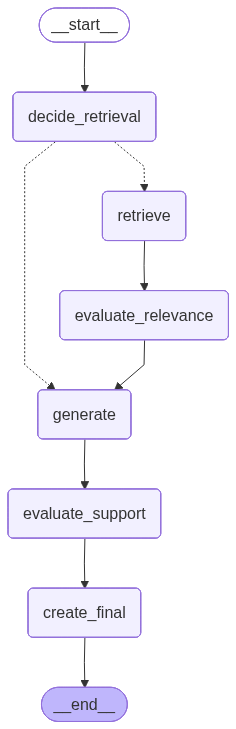

In [19]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            self_rag_app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 7. Self-RAG 시스템 실행 함수

사용자가 쉽게 사용할 수 있는 실행 함수를 만듭니다.


### Self-RAG 시스템을 실행하는 메인 함수

In [23]:
def run_self_rag(question: str, verbose: bool = True):
    """Self-RAG 시스템을 실행하는 메인 함수"""
    
    print(f"질문: {question}")
    print("=" * 50)
    
    # 초기 상태 설정
    initial_state = {
        "question": question,
        "retrieved_docs": [],
        "relevant_docs": [],
        "sources": [],
        "relevance_score": 0.0,
        "support_score": 0.0,
        "utility_score": 0.0,
    }
    
    # Self-RAG 워크플로우 실행
    try:
        result = self_rag_app.invoke(initial_state,
            config = {"configurable": {"thread_id": "self_rag_id"}}
            )
        
        if verbose:
            print("\n=== Self-RAG 실행 결과 ===")
            print(f"검색 필요성: {'필요' if result['need_retrieval'] else '불필요'}")
            print(f"검색된 문서 수: {len(result['retrieved_docs'])}")
            print(f"관련 문서 수: {len(result['relevant_docs'])}")
            print(f"관련성 점수: {result['relevance_score']:.2f}")
            print(f"지지도 점수: {result['support_score']:.2f}")
            print(f"신뢰도: {result['confidence']}")
            print(f"출처 수: {len(result['sources'])}")
            print("\n=== 최종 답변 ===")
        
        print(result["final_answer"])
        
        return result
        
    except Exception as e:
        error_message = f"Self-RAG 실행 중 오류가 발생했습니다: {str(e)}"
        print(error_message)
        return {"final_answer": "죄송하지만 시스템 오류로 인해 답변을 제공할 수 없습니다."}

print("Self-RAG 실행 함수 구현 완료!")


Self-RAG 실행 함수 구현 완료!


## 8. 테스트 예제

다양한 질문으로 Self-RAG 시스템을 테스트해봅니다.


### 테스트 1: 기술 용어에 대한 질문 (검색 필요)

In [21]:
# 테스트 1: 기술 용어에 대한 질문 (검색 필요)
print("테스트 1: 기술 용어 질문")
result1 = run_self_rag("CSS가 무엇인가요?")
print("\n" + "="*80 + "\n")


테스트 1: 기술 용어 질문
질문: CSS가 무엇인가요?
검색 필요성 판단: 필요
5개의 문서를 검색했습니다.
1개의 관련 문서를 선별했습니다. (평균 관련성: 5.00)
답변 생성 완료. 출처: 1개
지지도 평가: 5.0/5
최종 답변 생성 완료

=== Self-RAG 실행 결과 ===
검색 필요성: 필요
검색된 문서 수: 5
관련 문서 수: 1
관련성 점수: 5.00
지지도 점수: 5.00
신뢰도: medium
출처 수: 1

=== 최종 답변 ===
CSS는 HTML 요소의 스타일과 레이아웃을 정의하는 스타일시트 언어입니다. 색상, 폰트, 간격, 배치 등을 제어하여 웹 페이지의 시각적 표현을 담당합니다. 예시: body { color: blue; }는 웹 페이지의 텍스트 색상을 파란색으로 설정합니다. 관련 키워드: 웹 디자인, 스타일링, 레이아웃.

**출처:**
1. 파일: web-keywords.txt





### 테스트 2: 일반적인 인사말 (검색 불필요)

In [24]:
# 테스트 2: 일반적인 인사말 (검색 불필요)
print("테스트 2: 일반적인 인사말")
result2 = run_self_rag("안녕, 나는 홍길동이야.")
print("\n" + "="*80 + "\n")


테스트 2: 일반적인 인사말
질문: 안녕, 나는 홍길동이야.
검색 필요성 판단: 불필요
관련 문서가 없어 일반적인 답변을 생성합니다.

=== Self-RAG 실행 결과 ===
검색 필요성: 불필요
검색된 문서 수: 0
관련 문서 수: 0
관련성 점수: 0.00
지지도 점수: 0.00
신뢰도: unknown
출처 수: 0

=== 최종 답변 ===
안녕하세요, 홍길동님! 반갑습니다. 무엇을 도와드릴까요? 궁금한 점이 있으면 언제든 말씀해 주세요. 오늘 대화 주제나 관심 있는 분야가 있다면 알려주시면 같이 이야기해볼게요.




### 테스트 3: 데이터베이스에 없는 내용 (모른다고 답변)

In [25]:
# 테스트 3: 데이터베이스에 없는 내용 (모른다고 답변)
print("테스트 3: 알 수 없는 질문")
result3 = run_self_rag("양자컴퓨터의 작동 원리는 무엇인가요?")
print("\n" + "="*80 + "\n")


테스트 3: 알 수 없는 질문
질문: 양자컴퓨터의 작동 원리는 무엇인가요?
검색 필요성 판단: 필요
5개의 문서를 검색했습니다.
0개의 관련 문서를 선별했습니다. (평균 관련성: 0.00)
관련 문서가 없어 일반적인 답변을 생성합니다.

=== Self-RAG 실행 결과 ===
검색 필요성: 필요
검색된 문서 수: 5
관련 문서 수: 0
관련성 점수: 0.00
지지도 점수: 0.00
신뢰도: unknown
출처 수: 0

=== 최종 답변 ===
죄송하지만 해당 질문에 대한 정확한 정보를 제공할 수 없습니다.




### 테스트 4: 복합적인 기술 질문 (검색 필요, 출처 표시)

In [26]:
# 테스트 4: 복합적인 기술 질문 (검색 필요, 출처 표시)
print("테스트 4: 복합적인 기술 질문")
result4 = run_self_rag("임베딩과 벡터스토어의 관계는 무엇인가요?")
print("\n" + "="*80 + "\n")


테스트 4: 복합적인 기술 질문
질문: 임베딩과 벡터스토어의 관계는 무엇인가요?
검색 필요성 판단: 필요
5개의 문서를 검색했습니다.
4개의 관련 문서를 선별했습니다. (평균 관련성: 3.50)
답변 생성 완료. 출처: 4개
지지도 평가: 5.0/5
최종 답변 생성 완료

=== Self-RAG 실행 결과 ===
검색 필요성: 필요
검색된 문서 수: 5
관련 문서 수: 4
관련성 점수: 3.50
지지도 점수: 5.00
신뢰도: high
출처 수: 4

=== 최종 답변 ===
다음과 같이 요약할 수 있습니다.

- 임베딩(Embedding): 텍스트 데이터를 저차원의 연속 벡터로 변환하는 과정입니다. 예를 들어 "사과"를 [0.65, -0.23, 0.17] 같은 벡터로 표현합니다.

- 벡터스토어(VectorStore): 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 예시로는 임베딩 벡터들을 데이터베이스에 저장하여 빠르게 접근하는 것이 있습니다.

- 관계(임베딩과 벡터스토어의 연결고리):
  - 임베딩은 텍스트를 벡터로 변환하고,
  - 벡터스토어는 이렇게 변환된 벡터를 저장합니다.
  - 따라서 임베딩으로 생성된 벡터를 벡터스토어에 저장하고 관리하는 것이 두 개의 주요 역할입니다. 이로써 검색, 분류, 데이터 분석 등의 작업을 벡터 형태로 효율적으로 수행할 수 있습니다.

추가 참고:
- Word2Vec은 단어를 벡터 공간에 매핑하는 임베딩 방법의 하나입니다.
- 의미론적 검색(Semantic Search)은 키워드 매칭을 넘어 질의의 의미를 파악해 관련 결과를 반환하는 검색 방식입니다. 이 맥락에서 임베딩으로 생성된 벡터를 벡터스토어에 저장하고 활용하면 의미 기반 탐색에 도움이 될 수 있습니다.

**출처:**
1. 파일: rag-keywords.txt
2. 파일: rag-keywords.txt
3. 파일: rag-keywords.txt
4. 파일: rag-keywords.txt





## [Langsmith에서 확인하기](https://smith.langchain.com/)

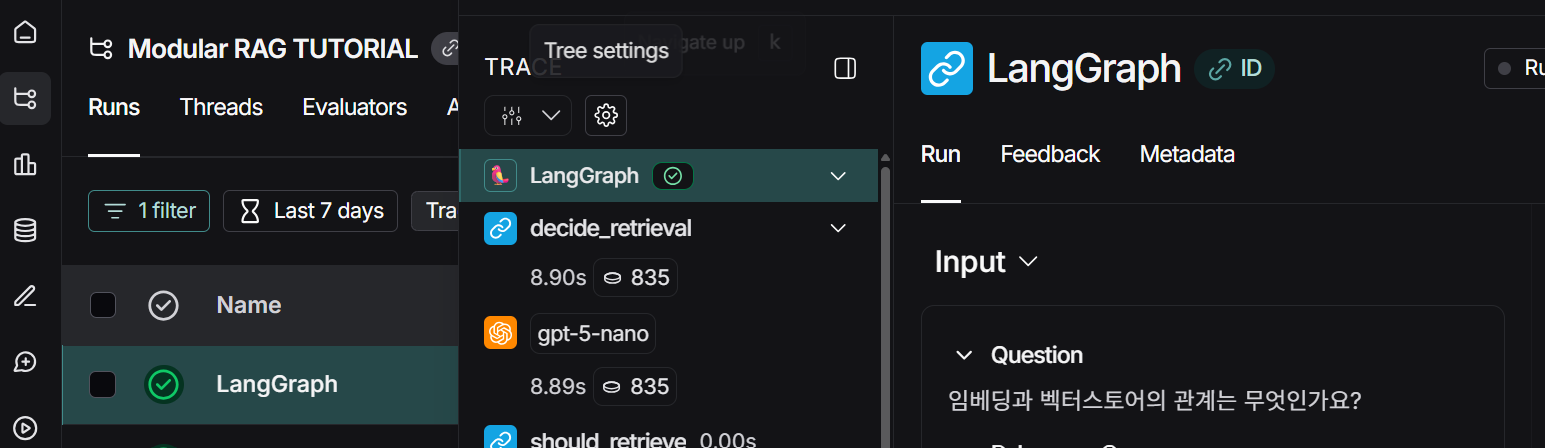